## Dataset Analysis


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [61]:
df = pd.read_csv("Stars.csv")
df.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


In [63]:
df.shape

(240, 7)

### 1. Separate out the categorical and numerical columns in dataset.

select_dtype() - separate it out based on - numerical or categorical 
- for numerical - include = int64 and float64
- for categorical - include = object


In [72]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns # for selecting the columns only

print(num_cols)
print(cat_cols)

# num_df = df.select_dtypes(include= 'number')
# cat_df = df.select_dtypes(exclude= 'number')
# or 

num_cols = num_cols.drop('Type')
print(num_cols)

num_df = df[num_cols]
cat_df = df[cat_cols]


Index(['Temperature', 'L', 'R', 'A_M', 'Type'], dtype='object')
Index(['Color', 'Spectral_Class'], dtype='object')
Index(['Temperature', 'L', 'R', 'A_M'], dtype='object')


In [73]:
num_df.head()

,Temperature,L,R,A_M
0,3068,0.002400,0.1700,16.12
1,3042,0.000500,0.1542,16.60
2,2600,0.000300,0.1020,18.70
3,2800,0.000200,0.1600,16.65
4,1939,0.000138,0.1030,20.06


In [74]:
cat_df.head()

,Color,Spectral_Class
0,Red,M
1,Red,M
2,Red,M
3,Red,M
4,Red,M


In [75]:
num_cols

Index(['Temperature', 'L', 'R', 'A_M'], dtype='object')

### 2. For each numeric attribute replace missing value with next value in records (row wise).and Perform Max-Min Normalization on each attribute and scale them in the range of 0-1.

In [64]:
missing = df.isna().sum()
print(missing)

Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
Type              0
dtype: int64


Max-Min Normalization formula:

n = (x - xmin)/(xmax - xmin)

In [76]:
num_df = num_df.bfill() 
# for filling the missing value with next value 
# use ffill for filling with the previous value

df[num_df.columns] = num_df
# num_col= num_col.drop('Type')

for col in num_df.columns:
    min_val = num_df[col].min()
    max_val = num_df[col].max()
    print(f"Max for {col}:",max_val)
    print(f"Min for {col}:",min_val)
    # print(min_val)
    df[col] = (df[col]-min_val)/(max_val - min_val)



Max for Temperature: 40000
Min for Temperature: 1939
Max for L: 849420.0
Min for L: 8e-05
Max for R: 1948.5
Min for R: 0.0084
Max for A_M: 20.06
Min for A_M: -11.92


In [77]:
df.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,0.029663,2.731275e-09,0.000083,0.876798,Red,M,0
1,0.028980,4.944550e-10,0.000075,0.891807,Red,M,0
2,0.017367,2.590003e-10,0.000048,0.957473,Red,M,0
3,0.022622,1.412729e-10,0.000078,0.893371,Red,M,0
4,0.000000,6.828189e-11,0.000049,1.000000,Red,M,0


### 3. Label Encode all the categorical attributes except the class label.

In [78]:
categorical_col = cat_cols


In [79]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_col:
    df[col] = le.fit_transform(df[col])

In [80]:
df.head(100)

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,0.029663,2.731275e-09,0.000083,0.876798,8,5,0
1,0.028980,4.944550e-10,0.000075,0.891807,8,5,0
2,0.017367,2.590003e-10,0.000048,0.957473,8,5,0
3,0.022622,1.412729e-10,0.000078,0.893371,8,5,0
4,0.000000,6.828189e-11,0.000049,1.000000,8,5,0
...,...,...,...,...,...,...,...
95,0.244634,7.911280e-04,0.003578,0.300813,4,0,3
96,0.083366,7.415884e-07,0.000445,0.519074,6,4,3
97,0.151888,9.323915e-06,0.000683,0.449031,15,2,3
98,0.266914,8.111416e-04,0.003593,0.373358,4,0,3


### 4. Fit the Logistic Regression Classifier with 70% Training Data.

In [87]:
X = df.drop('Type',axis=1)
y = df['Type']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X , y , test_size =.3 , random_state=42 )



In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

log_reg = LogisticRegression()

log_reg.fit(X_train, y_train)

y_pred=log_reg.predict(X_test)

print("Accuracy: ",metrics.accuracy_score(y_test, y_pred))

C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy:  0.9166666666666666


### 5. Find the least amount of training data required to get the best accuracy of 1.0 in Logistic regression classifier.

In [114]:

scores= []
sizes = []

max_size =0
max_score =0

for size in np.linspace(0.1,0.9,20):

    X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=size,random_state=42)
    logistic_reg = LogisticRegression(max_iter= 1000)
    logistic_reg.fit(X_train,y_train)

    y_pred = logistic_reg.predict(X_test)
    acc = metrics.accuracy_score(y_test,y_pred)

    sizes.append(size)
    scores.append(acc)
    
    if(acc > max_score):
        max_score = acc
        max_size = size

print(scores)
print(f"Max Score: {max_score * 100}")
print(f"Max Size: {(max_size)}")


[0.6666666666666666, 0.6650485436893204, 0.7244897959183674, 0.6612903225806451, 0.6306818181818182, 0.6807228915662651, 0.8397435897435898, 0.8904109589041096, 0.7794117647058824, 0.8333333333333334, 0.8, 0.819047619047619, 0.9157894736842105, 0.9294117647058824, 0.92, 0.8923076923076924, 0.8545454545454545, 0.8222222222222222, 0.8571428571428571, 0.9166666666666666]
Max Score: 92.94117647058823
Max Size: 0.6473684210526316


[]

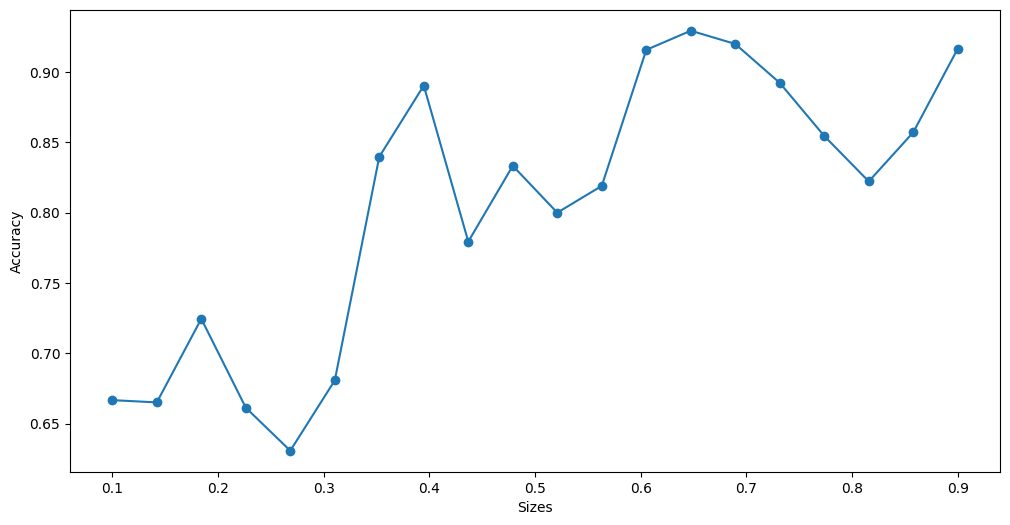

In [102]:
plt.figure(figsize=(12,6))
plt.plot(sizes, scores, marker='o')
plt.xlabel("Sizes")
plt.ylabel("Accuracy")
plt.plot()

### 6. Do we need all the attributes to get the best accuracy. Fit the classifier with different Permutations of features and determine the best feature set to get the maximum accuracy.

No, it is not needed to take all the attributes to get the best accuracy...

In [104]:
from itertools import combinations

X= df.drop('Type',axis=1)
y= df['Type']

best_score =0
best_features = None
features = X.columns

for r in range(1,len(features)+1):
    for combo in combinations(features, r):
        X_subset = X[list(combo)]
        X_train,X_test, y_train, y_test = train_test_split(
            X_subset, y, test_size=0.3, random_state=42
        )
        log = LogisticRegression(max_iter=1000)
        log.fit(X_train, y_train)

        y_pred = log.predict(X_test)
        acc = metrics.accuracy_score(y_test, y_pred)

        if acc > best_score:
            best_score = acc
            best_features = combo
        
print("Best Score: ", best_score)
print("Best Feature: ", best_features)


Best Score:  0.9583333333333334
Best Feature:  ('L', 'R', 'A_M', 'Spectral_Class')


### 7.Fit the SVM Classifier and determine the best learning rate at which maximum accuracy is achieved with least amount of training data. Plot amount of training data vs learning rate.


In [111]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop('Type', axis=1)
y = df['Type']

train_sizes = np.linspace(0.1, 0.9, 10)
val = [0.01, 0.1, 1, 10]

results = {}

for C in val:
    scores = []
    
    for size in train_sizes:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=size, random_state=42
        )
        
        model = SVC(C=C)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        
        scores.append(acc)
    
    results[C] = scores

results

{0.01: [0.16203703703703703,
  0.15384615384615385,
  0.20689655172413793,
  0.14473684210526316,
  0.2748091603053435,
  0.14545454545454545,
  0.13636363636363635,
  0.13432835820895522,
  0.13043478260869565,
  0.08333333333333333],
 0.1: [0.16203703703703703,
  0.15384615384615385,
  0.20689655172413793,
  0.23684210526315788,
  0.3893129770992366,
  0.4090909090909091,
  0.42045454545454547,
  0.44776119402985076,
  0.391304347826087,
  0.25],
 1: [0.5416666666666666,
  0.6307692307692307,
  0.5229885057471264,
  0.506578947368421,
  0.5038167938931297,
  0.5272727272727272,
  0.5568181818181818,
  0.5522388059701493,
  0.5,
  0.4583333333333333],
 10: [0.5601851851851852,
  0.676923076923077,
  0.6494252873563219,
  0.6381578947368421,
  0.6564885496183206,
  0.7,
  0.7272727272727273,
  0.7313432835820896,
  0.7391304347826086,
  0.7083333333333334]}

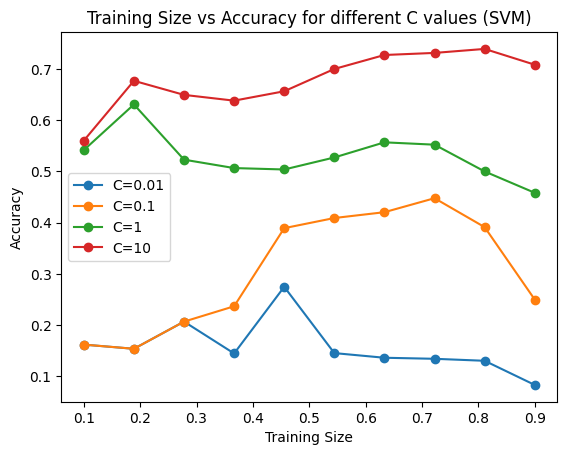

In [109]:

# Plot
plt.figure()

for C in val:
    plt.plot(train_sizes, results[C], marker='o', label=f"C={C}")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Training Size vs Accuracy for different C values (SVM)")
plt.legend()
plt.show()